In [3]:
import torch

import os, sys
sys.path.append('../src/')

import viz
import derivatives

## Gaussian

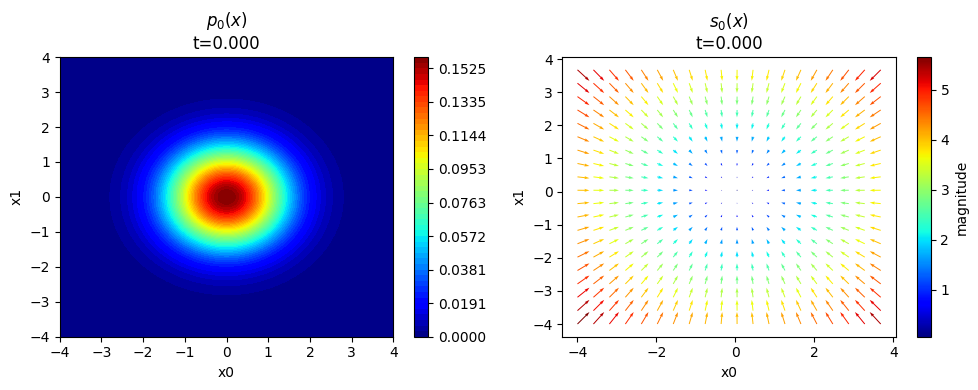

In [4]:
d = 2
gauss_dist = torch.distributions.MultivariateNormal(
    loc=torch.zeros(d),
    covariance_matrix=torch.eye(d),
)
p_ic = lambda X: torch.exp(gauss_dist.log_prob(X[:,:-1]))
L = 4.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.0*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}
plotter = viz.FunctionPlotter(**options)
plotter.add_panel('ic', title=r"$p_0(x)$").heatmap(p_ic)
def s0(x):
    x.detach()
    x.requires_grad_(True)
    q = gauss_dist.log_prob(x)
    s0 = derivatives.compute_grad(x, q, torch.ones_like(q)).detach()
    return s0
s_ic = lambda X: s0(X[:,:-1])
plotter.add_panel('ic', title=r"$s_0(x)$").quiver(s_ic)
plotter.show_plot(t_val=0.0)

## Cauchy

$$
\frac{1}{(1+||x||^2)^\frac{d+1}{2}}
$$

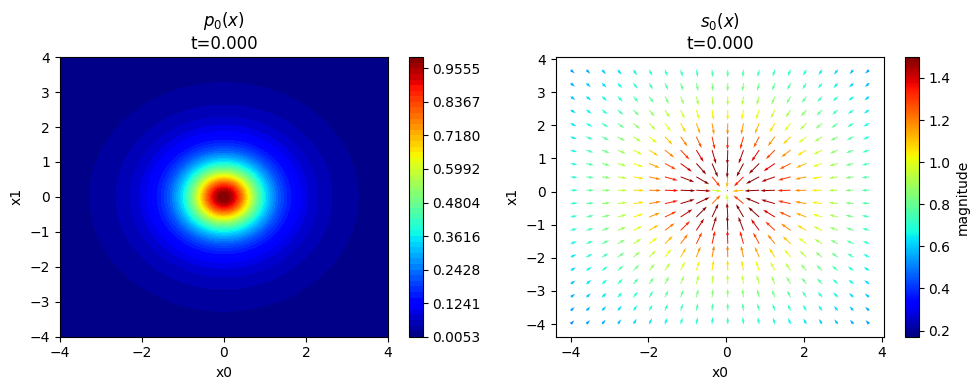

In [5]:
d = 2
def cauchy_dist(x):
    return 1 / ( 1 + (x**2).sum(dim=1) )**((d+1)/2)
p_ic = lambda X: cauchy_dist(X[:,:-1])
L = 4.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.0*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}
plotter = viz.FunctionPlotter(**options)
plotter.add_panel('ic', title=r"$p_0(x)$").heatmap(p_ic)
def s0(x):
    x.detach()
    x.requires_grad_(True)
    q = torch.log(cauchy_dist(x))
    s0 = derivatives.compute_grad(x, q, torch.ones_like(q)).detach()
    return s0
s_ic = lambda X: s0(X[:,:-1])
plotter.add_panel('ic', title=r"$s_0(x)$").quiver(s_ic)
plotter.show_plot(t_val=0.0)

## Laplace

$$
\prod_i e^{-|x_i|}
$$

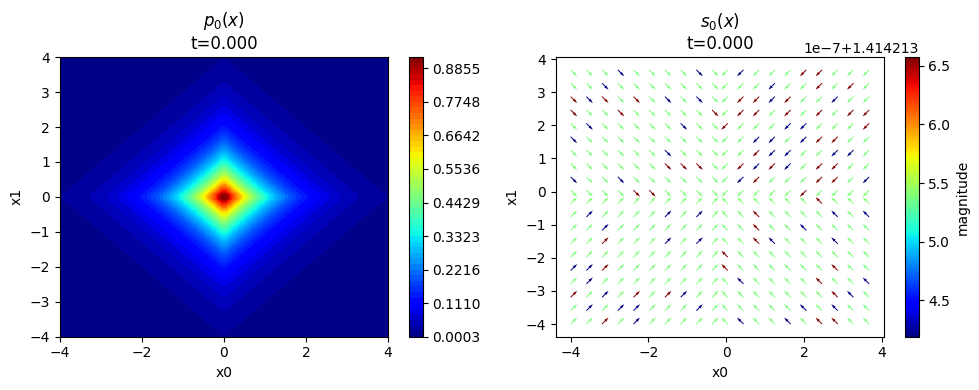

In [6]:
def laplace_dist(x):
    return torch.exp(-torch.abs(x)).prod(dim=1)
p_ic = lambda X: laplace_dist(X[:,:-1])
L = 4.0
options = {
    "d": d,
    "plot_dims": [0,1],
    "fixed_dims_vals": 0.0*torch.ones(d),
    "x_start": -L,
    "x_end": L,
}
plotter = viz.FunctionPlotter(**options)
plotter.add_panel('ic', title=r"$p_0(x)$").heatmap(p_ic)
def s0(x):
    x.detach()
    x.requires_grad_(True)
    q = torch.log(laplace_dist(x))
    s0 = derivatives.compute_grad(x, q, torch.ones_like(q)).detach()
    return s0
s_ic = lambda X: s0(X[:,:-1])
plotter.add_panel('ic', title=r"$s_0(x)$").quiver(s_ic)
plotter.show_plot(t_val=0.0)